In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

data_directory = Path.cwd() / "csv_files"
dalys  = pd.read_csv(data_directory / "dalys.CSV")
deaths = pd.read_csv(data_directory / "deaths.CSV")
ylds   = pd.read_csv(data_directory / "ylds.CSV")
ylls   = pd.read_csv(data_directory / "ylls.CSV")

def filtered_df(df):
    return df[
        (df["metric_name"] == "Count") &
        (df["sex_name"] == "All") &
        (df["age_group_name"] == "All Ages") &
        (df["counterfactual"] == "Drug-susceptible infection") &
        (df["infectious_syndrome"] == "All infectious syndromes")
    ].copy()

f_deaths = filtered_df(deaths)
f_dalys  = filtered_df(dalys)
f_ylls   = filtered_df(ylls)
f_ylds   = filtered_df(ylds)

keys = ["location_name", "pathogen", "antibiotic_class"]

f_deaths = f_deaths[keys + ['val']].rename(columns={'val': 'deaths'})
f_dalys  = f_dalys[keys  + ['val']].rename(columns={'val': 'dalys'})
f_ylls   = f_ylls[keys   + ['val']].rename(columns={'val': 'ylls'})
f_ylds   = f_ylds[keys   + ['val']].rename(columns={'val': 'ylds'})

merged = (f_deaths
          .merge(f_dalys, on=keys, how='inner')
          .merge(f_ylls,  on=keys, how='inner')
          .merge(f_ylds,  on=keys, how='inner'))

merged_clean = merged[
    ~merged['pathogen'].str.contains('All', case=False) &
    ~merged['antibiotic_class'].str.contains('one or more', case=False)
].copy()

print("Merged shape:", merged_clean.shape)

feature_matrix = (
    merged_clean
    .groupby(['pathogen', 'antibiotic_class'])
    .agg(
        total_deaths = ('deaths', 'sum'),
        total_ylds=('ylds', 'sum'),
    )
    .reset_index()
)

key_features = ['total_deaths', 'total_ylds']

feature_matrix[['total_deaths', 'total_ylds']] =( feature_matrix[['total_deaths', 'total_ylds']].clip(lower=0))

print("\nFeature matrix shape:", feature_matrix.shape)
print(feature_matrix.sort_values('total_deaths', ascending=False).head(5).to_string(index=False))

Merged shape: (3096, 7)

Feature matrix shape: (86, 4)
               pathogen                antibiotic_class  total_deaths  total_ylds
  Staphylococcus aureus                     Methicillin  46830.357949 4985.283317
       Escherichia coli                Fluoroquinolones  12833.137158 3865.011048
       Escherichia coli Third-generation cephalosporins  12545.404699 4146.879447
Acinetobacter baumannii                     Carbapenems  12324.422269  972.646257
 Pseudomonas aeruginosa                     Carbapenems  11685.306684 1578.409348


## Limitation Interpretations and Consideration for the Project

Check 1: There are no missing values, indicating that epidemiological modeling gave estimates for every cell. This is another consideration though, as some may be estimates, not directly observed

Check 2: Looks for country and combination coverage, like check 1, all of these exist, however are still estimates. 

Check 3: Examines how syndromes may lead to the same clusters but for sturcturally differing reasons, as some pathogens are generalized and account for multiple infection type and could lead to high burden as it is summed. This acts as a santiy check for clustering and understanding which type of syndrome is being examined.\
                                                 
Check 4: Checks for uncertaintly and the confidence intervals for point estimtes. From the data, this is relevant to data not used from observations but rather epidemiological modeling. Countries is especially important as variance in data collection is a concern for this project, as not all surveillance is created equal. Higher ranking countries listed mean more modeling estimates.

Check 5: Log distribution used as raw distribution contains a large spike near 0 (because most of the drug-pathogen combinations have low burden). This is useful for clustering, as the data may be mistakenly grouped into just extreme burden and low- burden.

Check 6: Looks at many patterns of uncertainty; are there antibiotics with globally poor tracking? Do certain countries have higher levels of uncertainty.                                                                                                                                                                              
                                                                                                                                                                
                                                                                                                                                

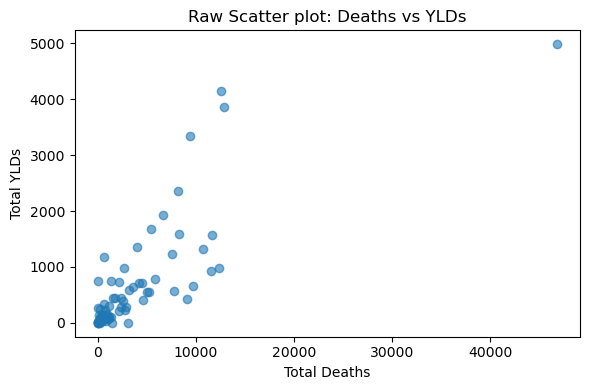

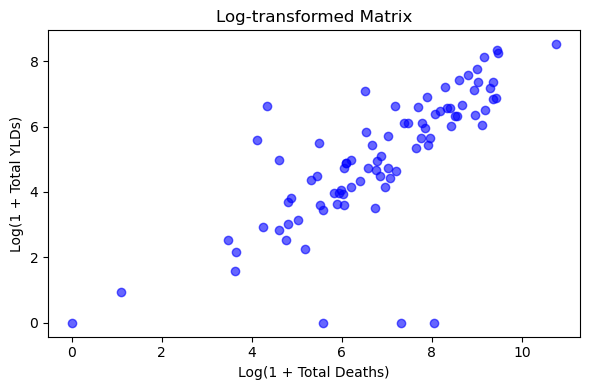

In [2]:
transform_matrix = np.log1p(feature_matrix[key_features])

sc = StandardScaler()
X_pca = sc.fit_transform(transform_matrix)


X = pd.DataFrame(X_pca, columns = key_features)
X['pathogen']=feature_matrix['pathogen'].values
X['antibiotic_class'] = feature_matrix['antibiotic_class'].values

plt.figure(figsize=(6,4))

plt.scatter(
    feature_matrix['total_deaths'],
    feature_matrix['total_ylds'],
    alpha=0.6
)

plt.xlabel("Total Deaths")
plt.ylabel("Total YLDs")
plt.title("Raw Scatter plot: Deaths vs YLDs")

plt.tight_layout()
plt.show()

log_deaths = np.log1p(feature_matrix['total_deaths'])
log_ylds   = np.log1p(feature_matrix['total_ylds'])

plt.figure(figsize=(6,4))

plt.scatter(
    log_deaths,
    log_ylds,
    alpha=0.6,
    color='blue'
)

plt.xlabel("Log(1 + Total Deaths)")
plt.ylabel("Log(1 + Total YLDs)")
plt.title("Log-transformed Matrix")

plt.tight_layout()
plt.show()

In [3]:
 
k  = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
feature_matrix['km_cluster'] = km.fit_predict(X_pca)


order = (feature_matrix.groupby('km_cluster')['total_deaths'].mean().sort_values().index)


label_map = dict(zip(order, ['Low', 'Moderate', 'High']))


feature_matrix['km_label'] = feature_matrix['km_cluster'].map(label_map)

print("Cluster profiles (mean raw values):")
print(feature_matrix.groupby('km_label')[['total_deaths','total_ylds']].mean().round(1))

print("\nCluster sizes:")
print(feature_matrix['km_label'].value_counts())

Cluster profiles (mean raw values):
          total_deaths  total_ylds
km_label                          
High            6919.2      1197.7
Low              408.5         8.6
Moderate         553.8       129.5

Cluster sizes:
km_label
High        37
Moderate    35
Low         14
Name: count, dtype: int64


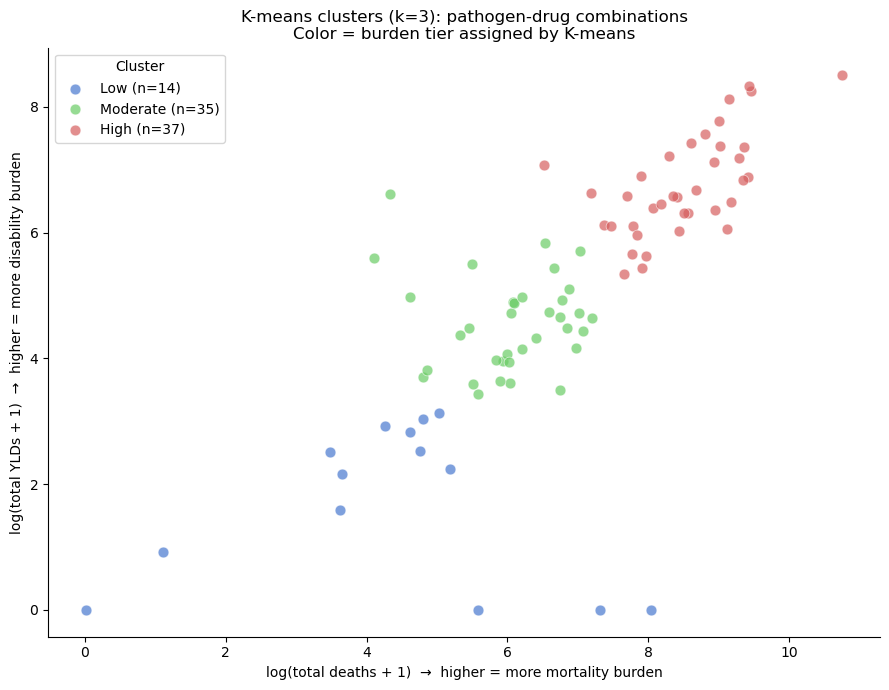

In [4]:
cluster_colors = {
    'Low':      '#4878CF',
    'Moderate': '#6ACC65',
    'High':     '#D65F5F'
}

cluster_order = ['Low', 'Moderate', 'High']

 
fig, ax = plt.subplots(figsize=(9, 7))
for label in cluster_order:
    group = feature_matrix[feature_matrix['km_label'] == label]
    ax.scatter(
        np.log1p(group['total_deaths']),
        np.log1p(group['total_ylds']),
        label=f"{label} (n={len(group)})",
        color=cluster_colors[label],
        alpha=0.7, s=60, edgecolors='white', linewidths=0.5
    )
 
ax.set_xlabel('log(total deaths + 1)  →  higher = more mortality burden')
ax.set_ylabel('log(total YLDs + 1)  →  higher = more disability burden')
ax.set_title('K-means clusters (k=3): pathogen-drug combinations\n'
             'Color = burden tier assigned by K-means')
ax.legend(title='Cluster')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


Median disability ratio (ylds / deaths) per cluster:
km_label
High        0.163
Low         0.152
Moderate    0.155
Name: disability_ratio, dtype: float64

Interpretation: higher ratio = more disability relative to deaths


/tmp/ipykernel_513/3649595004.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_plot, labels=cluster_order, patch_artist=True)


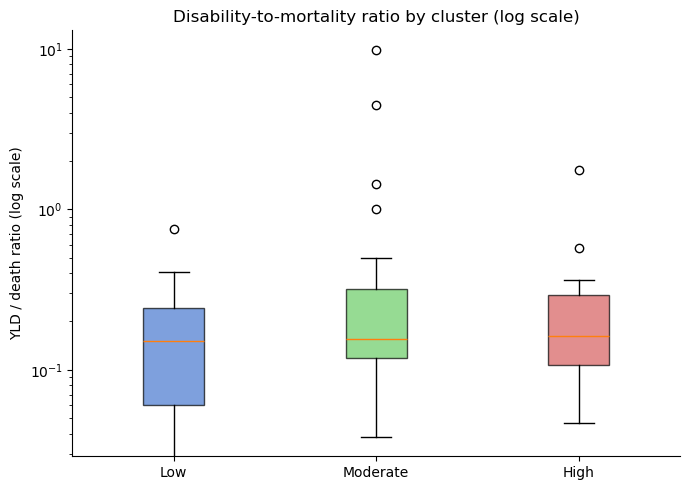

In [5]:
#disability ratio - are cluster mortality or morbidity dominant?

feature_matrix['disability_ratio'] = (
    feature_matrix['total_ylds'] / (feature_matrix['total_deaths'] + 1e-9)
)

print("Median disability ratio (ylds / deaths) per cluster:")
print(feature_matrix.groupby('km_label')['disability_ratio'].median().round(3))
print("\nInterpretation: higher ratio = more disability relative to deaths")


fig, ax = plt.subplots(figsize=(7, 5))

data_for_plot = [
    feature_matrix[feature_matrix['km_label'] == label]['disability_ratio'].values
    for label in cluster_order
]

bp = ax.boxplot(data_for_plot, labels=cluster_order, patch_artist=True)

for patch, label in zip(bp['boxes'], cluster_order):
    patch.set_facecolor(cluster_colors[label])
    patch.set_alpha(0.7)

ax.set_yscale('log')
ax.set_ylabel('YLD / death ratio (log scale)')
ax.set_title('Disability-to-mortality ratio by cluster (log scale)')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
#drug-pathogen combos per cluster

for label in cluster_order:
    subset = (feature_matrix[feature_matrix['km_label'] == label]
              [['pathogen','antibiotic_class','total_deaths','total_ylds']]
              .sort_values('total_deaths', ascending=False))
    print(f"\n{label.upper()} BURDEN (n={len(subset)}):")
    print(subset.to_string(index=False))


LOW BURDEN (n=14):
                  pathogen                                                antibiotic_class  total_deaths  total_ylds
  Streptococcus pneumoniae                                                       Macrolide   3116.586813    0.000000
Mycobacterium tuberculosis Multi-drug resistance excluding extensive drug resistance in TB   1494.373955    0.000000
Mycobacterium tuberculosis                                 Extensive drug resistance in TB    263.008190    0.000000
   Acinetobacter baumannii                           Beta Lactam/Beta-lactamase inhibitors    178.128703    8.467135
          Citrobacter spp.                                                     Carbapenems    152.073299   21.972178
     Group B Streptococcus                                                      Penicillin    121.264587   19.685514
           Morganella spp.                                                Fluoroquinolones    115.655376   11.459689
          Citrobacter spp.                  